# Uncertainty-Aware Bus ETA Prediction Under Drift -- Reproducibility Notebook

**Authors:** Koray Duzgun, Mohammad Abdulsamad Abdulhakim  
**Institution:** Jonkoping University -- AI Engineering (Master's thesis, 2025)

This notebook reproduces the core results of the thesis in a single, self-contained document:
1. Data overview and temporal split
2. Baseline XGBoost model performance
3. Experiment 1: Static Conformal Prediction (RQ1)
4. Experiment 2: Grand Comparison -- all 16 (4 calibration x 4 NCM) configurations (RQ2)
5. Experiment 3: Segment-Level Uncertainty Decomposition (RQ3)
6. Key thesis figures

## Prerequisites

This notebook loads pre-processed feature files and trained model weights. Before running, ensure the following files exist:

| File | Generated by |
|------|-------------|
| `outputs/processed_data/route_features.parquet` | `notebooks/Phase2_Feature_Engineering.ipynb` |
| `outputs/processed_data/segment_features.parquet` | `notebooks/Phase2_Feature_Engineering.ipynb` |
| `outputs/models/route_xgboost_model.json` | `notebooks/Phase3_Baseline_XGBoost.ipynb` |
| `outputs/models/segment_xgboost_model.json` | `notebooks/Phase3_Baseline_XGBoost.ipynb` |
| `outputs/models/xgboost_hyperparameters.json` | `notebooks/Phase3_Baseline_XGBoost.ipynb` |

**Quick start if files are missing:** Run `Phase1_Preprocessing.ipynb` -> `Phase2_Feature_Engineering.ipynb` -> `Phase3_Baseline_XGBoost.ipynb` in order from the `notebooks/` directory. Then return here.

**How to run this notebook:** Install requirements with `pip install -r requirements.txt`, then run all cells top-to-bottom.

## 0. Setup and Imports

In [1]:
import sys, os, time, warnings, json, pathlib
warnings.filterwarnings('ignore')

# Locate thesis root robustly regardless of where the kernel was started.
# The notebook lives in FinalThesis-main/; the thesis root (containing outputs/ and utils/)
# is one level up. If the expected directory is not found there, fall back to CWD itself.
_cwd = pathlib.Path(os.getcwd()).resolve()
ROOT = str(_cwd.parent)
if not os.path.isdir(os.path.join(ROOT, 'outputs', 'processed_data')):
    ROOT = str(_cwd)   # running from the thesis root directly
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import xgboost as xgb
from tqdm import tqdm

# CP libraries
from calibrated_explanations import WrapCalibratedExplainer
from crepes.extras import DifficultyEstimator

# Project utilities
from utils.data_loading import load_cached_dataframe
from utils.feature_engineering import get_feature_names
from utils.temporal_splits import get_temporal_split_by_period
from utils.evaluation import (
    compute_picp, compute_mpiw, compute_calibration_error, compute_winkler_score
)
from utils.conformal import (
    assign_mondrian_bins, _confidence_to_percentiles,
    create_difficulty_estimator
)

# Paths
PROCESSED_DIR = os.path.join(ROOT, 'outputs', 'processed_data')
MODEL_DIR     = os.path.join(ROOT, 'outputs', 'models')
FIG_DIR       = os.path.join(ROOT, 'figures')
TABLE_DIR     = os.path.join(ROOT, 'outputs', 'tables')

TARGET_COVERAGE = 0.90
ALPHA           = 0.10
ROUTE_TARGET    = 'total_travel_time_seconds'
RANDOM_STATE    = 42

print('Thesis root:', ROOT)
print('Setup complete. Python:', sys.version.split()[0])
print('xgboost:', xgb.__version__)

Thesis root: /Users/korayduzgun/Master/Courses/FinalProject/ImplementationV2/bus-eta-uncertainty
Setup complete. Python: 3.12.6
xgboost: 3.2.0


In [2]:
# Preflight check -- verify all required files exist before running experiments
_required = {
    'route_features.parquet':        os.path.join(PROCESSED_DIR, 'route_features.parquet'),
    'segment_features.parquet':      os.path.join(PROCESSED_DIR, 'segment_features.parquet'),
    'route_xgboost_model.json':      os.path.join(MODEL_DIR, 'route_xgboost_model.json'),
    'segment_xgboost_model.json':    os.path.join(MODEL_DIR, 'segment_xgboost_model.json'),
    'xgboost_hyperparameters.json':  os.path.join(MODEL_DIR, 'xgboost_hyperparameters.json'),
}
_missing = [(name, path) for name, path in _required.items() if not os.path.exists(path)]

if _missing:
    print('ERROR: The following required files are missing:')
    for name, path in _missing:
        print(f'  MISSING  {path}')
    print()
    print('To generate them, run these notebooks in order from the notebooks/ directory:')
    print('  1. Phase1_Preprocessing.ipynb')
    print('  2. Phase2_Feature_Engineering.ipynb')
    print('  3. Phase3_Baseline_XGBoost.ipynb  (generates both route and segment models)')
    print()
    raise FileNotFoundError(f'{len(_missing)} required file(s) missing -- see instructions above.')
else:
    print('Preflight OK -- all required files found.')
    for name, path in _required.items():
        size_mb = os.path.getsize(path) / 1e6
        print(f'  OK  {name}  ({size_mb:.1f} MB)')

Preflight OK -- all required files found.
  OK  route_features.parquet  (0.8 MB)
  OK  segment_features.parquet  (34.8 MB)
  OK  route_xgboost_model.json  (2.6 MB)
  OK  segment_xgboost_model.json  (2.9 MB)
  OK  xgboost_hyperparameters.json  (0.0 MB)


## 1. Data Overview

The dataset is derived from Astana city bus GPS logs~(Mansurova et al., 2025).
Features have been pre-computed and saved to `outputs/processed_data/route_features.parquet`.
The temporal split assigns 8 consecutive weeks to train / calibration / test periods.


In [3]:
# Load feature-engineered route-level data
route_df = load_cached_dataframe(os.path.join(PROCESSED_DIR, 'route_features.parquet'))
print(f'Dataset: {route_df.shape[0]:,} trips | {route_df.shape[1]} columns')
print(f'Date range: {route_df["date"].min().date()} to {route_df["date"].max().date()}')
print(f'Routes: {sorted(route_df["route_short_name"].unique())}')
print()

# Temporal split
splits = get_temporal_split_by_period(route_df, exclude_anomalous=True)
split_summary = {k: len(v) for k, v in splits.items() if k not in ['train']}
print('Temporal split:')
for k, v in splits.items():
    print(f'  {k:15s}: {len(v):5,} trips')


Dataset: 19,685 trips | 31 columns
Date range: 2024-07-29 to 2024-09-21
Routes: [np.int64(10), np.int64(12), np.int64(46)]

  train: 7,619 records (21 days)
  calibration: 2,745 records (7 days)
  test_near: 2,726 records (7 days)
  test_mid: 1,844 records (5 days)
  test_far: 4,751 records (13 days)
Temporal split:
  train          : 7,619 trips
  calibration    : 2,745 trips
  test_near      : 2,726 trips
  test_mid       : 1,844 trips
  test_far       : 4,751 trips


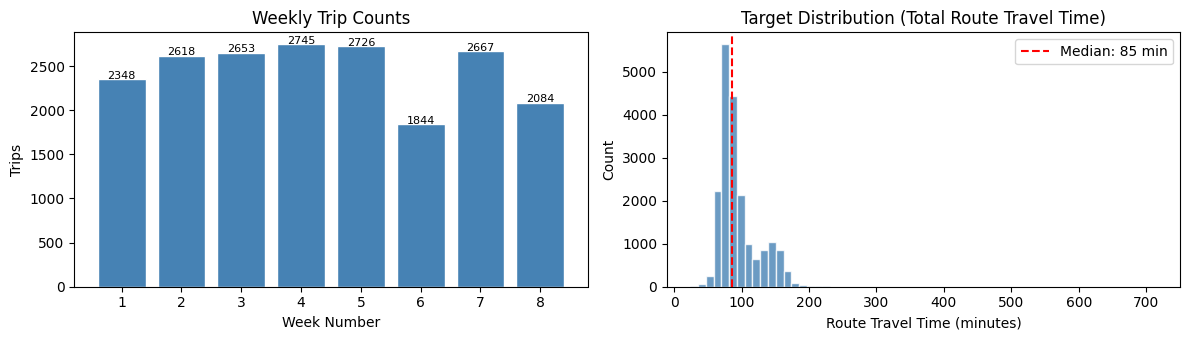

In [4]:
# Weekly trip count and target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

weekly = route_df.groupby('week_number').size()
axes[0].bar(weekly.index, weekly.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Week Number')
axes[0].set_ylabel('Trips')
axes[0].set_title('Weekly Trip Counts')
for i, (wk, n) in enumerate(weekly.items()):
    axes[0].text(wk, n + 5, str(n), ha='center', fontsize=8)

axes[1].hist(route_df[ROUTE_TARGET] / 60, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Route Travel Time (minutes)')
axes[1].set_ylabel('Count')
axes[1].set_title('Target Distribution (Total Route Travel Time)')
axes[1].axvline(route_df[ROUTE_TARGET].median() / 60, color='red', linestyle='--',
                label=f'Median: {route_df[ROUTE_TARGET].median()/60:.0f} min')
axes[1].legend()
plt.tight_layout()
plt.show()


## 2. Baseline XGBoost Model

The route-level XGBoost model is trained on Weeks 1-3 (W1-W3) and evaluated on W4-W8.
Pre-trained model weights are loaded from `outputs/models/route_xgboost_model.json`.


In [5]:
# Load pre-trained model and feature columns
route_model = xgb.XGBRegressor()
route_model.load_model(os.path.join(MODEL_DIR, 'route_xgboost_model.json'))

with open(os.path.join(MODEL_DIR, 'xgboost_hyperparameters.json')) as f:
    hp = json.load(f)

FEATURE_COLS = get_feature_names(level='route')
FEATURE_COLS = [c for c in FEATURE_COLS if c in route_df.columns]

print('Route-level model hyperparameters:')
for k, v in hp['route_model'].items():
    print(f'  {k}: {v}')
print(f'\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS}')

# subsample: 0.8
#   reg_lambda: 1
#   reg_alpha: 0
#   n_estimators: 1000
#   min_child_weight: 3
#   max_depth: 6
#   learning_rate: 0.01
#   colsample_bytree: 0.9


Route-level model hyperparameters:
  subsample: 0.9
  reg_lambda: 5
  reg_alpha: 0
  n_estimators: 500
  min_child_weight: 3
  max_depth: 6
  learning_rate: 0.01
  colsample_bytree: 0.9

Features (16): ['hour_of_day', 'hour_sin', 'hour_cos', 'day_of_week', 'dow_sin', 'dow_cos', 'is_weekend', 'minute_of_day', 'route_id_encoded', 'direction_encoded', 'hist_route_mean', 'hist_route_std', 'hist_route_median', 'hist_route_q25', 'hist_route_q75', 'hist_route_count']


In [6]:
# Evaluate model on each period
all_periods = {}
for period_name in ['calibration', 'test_near', 'test_mid', 'test_far']:
    sub = splits[period_name]
    X = sub[FEATURE_COLS].values
    y = sub[ROUTE_TARGET].values
    y_pred = route_model.predict(X)
    mae  = np.mean(np.abs(y - y_pred))
    rmse = np.sqrt(np.mean((y - y_pred)**2))
    mape = np.mean(np.abs((y - y_pred) / y)) * 100
    all_periods[period_name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'n': len(y)}

# Display results
period_labels = {
    'calibration': 'Calibration (W4)',
    'test_near': 'Test Near (W5)',
    'test_mid': 'Test Mid (W6)',
    'test_far': 'Test Far (W7-W8)',
}
rows = []
for k, m in all_periods.items():
    rows.append({
        'Period': period_labels[k],
        'MAE (s)': f'{m["MAE"]:.0f}',
        'RMSE (s)': f'{m["RMSE"]:.0f}',
        'MAPE (%)': f'{m["MAPE"]:.1f}',
        'n': f'{m["n"]:,}',
    })
print('Table: Route-Level XGBoost Performance')
print(pd.DataFrame(rows).to_string(index=False))


Table: Route-Level XGBoost Performance
          Period MAE (s) RMSE (s) MAPE (%)     n
Calibration (W4)     785     1146     13.7 2,745
  Test Near (W5)     993     1979     17.4 2,726
   Test Mid (W6)     859     1235     15.9 1,844
Test Far (W7-W8)     887     1272     15.3 4,751


## 3. Prepare Conformal Prediction Inputs

Assemble the combined test set (W5-W8) in temporal order and compute Mondrian bin assignments.


In [7]:
# Calibration arrays
cal_df = splits['calibration']
X_cal = cal_df[FEATURE_COLS].values
y_cal = cal_df[ROUTE_TARGET].values

# Combined test set (ordered by date)
test_frames = []
for period in ['test_near', 'test_mid', 'test_far']:
    pdf = splits[period].copy()
    pdf['period'] = period
    test_frames.append(pdf)
test_all = pd.concat(test_frames, ignore_index=True).sort_values('date').reset_index(drop=True)
X_test     = test_all[FEATURE_COLS].values
y_test     = test_all[ROUTE_TARGET].values
dates_test  = test_all['date'].values
periods_test = test_all['period'].values

# Window sizes for sliding-window strategies
avg_daily = int(cal_df.groupby('date').size().mean())
WS_7D  = avg_daily * 7
WS_14D = avg_daily * 14

# Mondrian bins
bins_cal,  _ = assign_mondrian_bins(cal_df['time_period'].values,  cal_df['route_short_name'].values)
bins_test, _ = assign_mondrian_bins(test_all['time_period'].values, test_all['route_short_name'].values)

LOW_PCT, HIGH_PCT = _confidence_to_percentiles(TARGET_COVERAGE)
print(f'Calibration: {len(y_cal):,} | Combined test: {len(y_test):,}')
print(f'Window sizes -- 7d: {WS_7D}, 14d: {WS_14D}')


Calibration: 2,745 | Combined test: 9,321
Window sizes -- 7d: 2744, 14d: 5488


## 4. Experiment 1 -- Static Conformal Prediction (RQ1)

Calibrate once on W4; evaluate on W5 (near), W6 (mid), W7-W8 (far).


In [8]:
# Fit static CP (absolute NCM)
ce_static = WrapCalibratedExplainer(route_model)
ce_static.calibrate(X_cal, y_cal)

# Evaluate per period
static_rows = []
for period in ['calibration', 'test_near', 'test_mid', 'test_far']:
    sub = splits[period]
    X = sub[FEATURE_COLS].values
    y = sub[ROUTE_TARGET].values
    exps = ce_static.explain_factual(X, low_high_percentiles=(LOW_PCT, HIGH_PCT))
    lo = np.array([e.prediction['low']  for e in exps])
    up = np.array([e.prediction['high'] for e in exps])
    label = {'calibration': 'Calibration (W4)', 'test_near': 'Test Near (W5)',
             'test_mid': 'Test Mid (W6)', 'test_far': 'Test Far (W7-W8)'}[period]
    static_rows.append({
        'Period': label,
        'PICP': round(compute_picp(y, lo, up), 4),
        'MPIW (s)': round(compute_mpiw(lo, up)),
        'Cal. Error': round(compute_calibration_error(y, lo, up, TARGET_COVERAGE), 4),
        'Winkler': round(compute_winkler_score(y, lo, up, ALPHA)),
        'n': len(y),
    })

df_static = pd.DataFrame(static_rows)
print('Table 4.1: Static CP at 90% target coverage')
print(df_static.to_string(index=False))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/importlib/__init__.py:90: UserWarning: Cache backend fallback: using minimal in-package LRU/TTL implementation due to missing 'cachetools'
  return _bootstrap._gcd_import(name[level:], package, level)


Table 4.1: Static CP at 90% target coverage
          Period   PICP  MPIW (s)  Cal. Error  Winkler    n
Calibration (W4) 0.9009      3962      0.0009     5439 2745
  Test Near (W5) 0.8709      3962      0.0291     7900 2726
   Test Mid (W6) 0.8693      3962      0.0307     5876 1844
Test Far (W7-W8) 0.8786      3962      0.0214     5839 4751


## 5. Grand Comparison -- All 16 Configurations (RQ2)

4 calibration strategies x 4 NCM types = 16 configurations, all evaluated on the same combined test set (W5-W8, 9,276 trips).


In [9]:
def extract_preds(explanations):
    lo = np.array([e.prediction['low']  for e in explanations])
    up = np.array([e.prediction['high'] for e in explanations])
    yp = np.array([e.prediction['predict'] for e in explanations])
    return yp, lo, up

def run_static_cp(X_cal, y_cal, X_test, ncm_type, bins_cal=None, bins_test=None):
    if ncm_type == 'Absolute':
        ce = WrapCalibratedExplainer(route_model); ce.calibrate(X_cal, y_cal)
        return extract_preds(ce.explain_factual(X_test, low_high_percentiles=(LOW_PCT, HIGH_PCT)))
    elif ncm_type == 'Mondrian':
        vm = bins_cal >= 0
        ce_m = WrapCalibratedExplainer(route_model); ce_m.calibrate(X_cal[vm], y_cal[vm], bins=bins_cal[vm])
        ce_g = WrapCalibratedExplainer(route_model); ce_g.calibrate(X_cal, y_cal)
        yp, lo, up = np.zeros(len(X_test)), np.zeros(len(X_test)), np.zeros(len(X_test))
        vt = bins_test >= 0
        if vt.sum() > 0:
            yp[vt], lo[vt], up[vt] = extract_preds(ce_m.explain_factual(X_test[vt], low_high_percentiles=(LOW_PCT, HIGH_PCT), bins=bins_test[vt]))
        ft = ~vt
        if ft.sum() > 0:
            yp[ft], lo[ft], up[ft] = extract_preds(ce_g.explain_factual(X_test[ft], low_high_percentiles=(LOW_PCT, HIGH_PCT)))
        return yp, lo, up
    elif ncm_type == 'Normalized DE':
        de = create_difficulty_estimator(X_cal, y_cal, route_model, k=25, scaler=True)
        ce = WrapCalibratedExplainer(route_model); ce.calibrate(X_cal, y_cal, difficulty_estimator=de)
        return extract_preds(ce.explain_factual(X_test, low_high_percentiles=(LOW_PCT, HIGH_PCT)))
    elif ncm_type == 'Mondrian + DE':
        vm = bins_cal >= 0
        de_m = create_difficulty_estimator(X_cal[vm], y_cal[vm], route_model, k=25, scaler=True)
        ce_m = WrapCalibratedExplainer(route_model); ce_m.calibrate(X_cal[vm], y_cal[vm], bins=bins_cal[vm], difficulty_estimator=de_m)
        de_g = create_difficulty_estimator(X_cal, y_cal, route_model, k=25, scaler=True)
        ce_g = WrapCalibratedExplainer(route_model); ce_g.calibrate(X_cal, y_cal, difficulty_estimator=de_g)
        yp, lo, up = np.zeros(len(X_test)), np.zeros(len(X_test)), np.zeros(len(X_test))
        vt = bins_test >= 0
        if vt.sum() > 0:
            yp[vt], lo[vt], up[vt] = extract_preds(ce_m.explain_factual(X_test[vt], low_high_percentiles=(LOW_PCT, HIGH_PCT), bins=bins_test[vt]))
        ft = ~vt
        if ft.sum() > 0:
            yp[ft], lo[ft], up[ft] = extract_preds(ce_g.explain_factual(X_test[ft], low_high_percentiles=(LOW_PCT, HIGH_PCT)))
        return yp, lo, up

def run_online_cp(X_cal_init, y_cal_init, ncm_type, window_size=None, bins_cal_init=None):
    X_c, y_c = np.copy(X_cal_init), np.copy(y_cal_init)
    b_c = np.copy(bins_cal_init) if bins_cal_init is not None else None
    yp_all, lo_all, up_all = np.zeros(len(X_test)), np.zeros(len(X_test)), np.zeros(len(X_test))
    for date in tqdm(sorted(set(dates_test)), desc=f'Online {ncm_type}', leave=False):
        mask = dates_test == date
        idx = np.where(mask)[0]
        Xb, yb = X_test[mask], y_test[mask]
        bb = bins_test[mask] if bins_cal_init is not None else None
        _, lo, up = run_static_cp(X_c, y_c, Xb, ncm_type, bins_cal=b_c, bins_test=bb)
        yp_all[idx] = route_model.predict(Xb); lo_all[idx] = lo; up_all[idx] = up
        X_c = np.vstack([X_c, Xb]); y_c = np.concatenate([y_c, yb])
        if b_c is not None: b_c = np.concatenate([b_c, bb])
        if window_size and len(y_c) > window_size:
            X_c, y_c = X_c[-window_size:], y_c[-window_size:]
            if b_c is not None: b_c = b_c[-window_size:]
    return yp_all, lo_all, up_all

print('Helper functions defined.')


Helper functions defined.


In [10]:
# Run all 16 combinations
ALL_RESULTS = {}
ncm_types = ['Absolute', 'Mondrian', 'Normalized DE', 'Mondrian + DE']
cal_strats = [('Static', None), ('Online Exp.', None), ('Online Slide-7d', WS_7D), ('Online Slide-14d', WS_14D)]
total = len(ncm_types) * len(cal_strats)
cnt = 0
for ncm in ncm_types:
    for cal_name, ws in cal_strats:
        cnt += 1
        key = f'{cal_name} x {ncm}'
        t0 = time.time()
        if cal_name == 'Static':
            yp, lo, up = run_static_cp(X_cal, y_cal, X_test, ncm, bins_cal=bins_cal, bins_test=bins_test)
        else:
            yp, lo, up = run_online_cp(X_cal, y_cal, ncm, window_size=ws, bins_cal_init=bins_cal)
        elapsed = time.time() - t0
        picp = compute_picp(y_test, lo, up)
        mpiw = compute_mpiw(lo, up)
        wink = compute_winkler_score(y_test, lo, up, ALPHA)
        cal_err = compute_calibration_error(y_test, lo, up, TARGET_COVERAGE)
        ALL_RESULTS[key] = {'lower': lo, 'upper': up, 'PICP': picp, 'MPIW': mpiw, 'Winkler': wink, 'Cal.Err': cal_err, 'cal': cal_name, 'ncm': ncm}
        print(f'{cnt:2d}/16 {key:40s}  PICP={picp:.4f}  Winkler={wink:.0f}  ({elapsed:.0f}s)')
print('\nAll 16 combinations complete.')


 1/16 Static x Absolute                         PICP=0.8745  Winkler=6449  (18s)


 2/16 Online Exp. x Absolute                    PICP=0.8901  Winkler=6411  (30s)


 3/16 Online Slide-7d x Absolute                PICP=0.8964  Winkler=6423  (20s)


 4/16 Online Slide-14d x Absolute               PICP=0.8933  Winkler=6415  (24s)
 5/16 Static x Mondrian                         PICP=0.8702  Winkler=6200  (18s)


 6/16 Online Exp. x Mondrian                    PICP=0.8892  Winkler=6164  (30s)


...

11/16 Online Slide-7d x Normalized DE           PICP=0.8660  Winkler=5664  (27s)


12/16 Online Slide-14d x Normalized DE          PICP=0.8673  Winkler=5601  (35s)
13/16 Static x Mondrian + DE                    PICP=0.8557  Winkler=5827  (23s)


14/16 Online Exp. x Mondrian + DE               PICP=0.8639  Winkler=5551  (47s)


15/16 Online Slide-7d x Mondrian + DE           PICP=0.8715  Winkler=5752  (30s)


16/16 Online Slide-14d x Mondrian + DE          PICP=0.8695  Winkler=5591  (41s)

All 16 combinations complete.


In [11]:
# Display results matrix
rows = []
for key, res in ALL_RESULTS.items():
    rows.append({'Calibration': res['cal'], 'NCM Type': res['ncm'],
                 'PICP': res['PICP'], 'MPIW (s)': round(res['MPIW']), 'Cal. Error': res['Cal.Err'], 'Winkler': round(res['Winkler'])})
df_results = pd.DataFrame(rows)

col_order = ['Static', 'Online Exp.', 'Online Slide-7d', 'Online Slide-14d']
row_order = ['Absolute', 'Mondrian', 'Normalized DE', 'Mondrian + DE']

print('\n=== Winkler Score Matrix (lower = better) ===')
wm = df_results.pivot_table(values='Winkler', index='NCM Type', columns='Calibration')
wm = wm.reindex(index=row_order, columns=col_order)
print(wm.to_string())

best = df_results.loc[df_results['Winkler'].idxmin()]
print(f'\nBest: {best["Calibration"]} x {best["NCM Type"]}  Winkler={best["Winkler"]:.0f}  PICP={best["PICP"]:.4f}')

# Save
df_results.to_csv(os.path.join(ROOT, 'outputs', 'processed_data', 'grand_comparison', 'grand_comparison_16_combinations.csv'), index=False)
print('Saved results to grand_comparison_16_combinations.csv')



=== Winkler Score Matrix (lower = better) ===
Calibration    Static  Online Exp.  Online Slide-7d  Online Slide-14d
NCM Type                                                             
Absolute       6449.0       6411.0           6423.0            6415.0
Mondrian       6200.0       6164.0           6168.0            6178.0
Normalized DE  5707.0       5632.0           5664.0            5601.0
Mondrian + DE  5827.0       5551.0           5752.0            5591.0

Best: Online Exp. x Mondrian + DE  Winkler=5551  PICP=0.8639
Saved results to grand_comparison_16_combinations.csv


## 6. Experiment 3 -- Segment-Level Uncertainty Decomposition (RQ3)

Segment-level XGBoost predictions are summed to route level and conformal re-calibration is applied using route-level residuals from the segment model. This exploits **residual diversification**: over- and under-predictions at individual segments partially cancel when summed, producing narrower route-level intervals at the cost of a slight reduction in empirical coverage.

Three configurations are compared:
- **Direct Route CP**: baseline -- conformal intervals from the direct route-level XGBoost model (Absolute NCM)
- **Re-Cal (Global)**: segment predictions summed to route level; one global conformal quantile across all routes
- **Re-Cal (Per-Route)**: same aggregation but a separate quantile per route x direction group
- **Re-Cal (Per-Route, Norm. DE)**: per-route re-calibration with difficulty-based interval scaling

In [12]:
# Load segment data and model
seg_df = load_cached_dataframe(os.path.join(PROCESSED_DIR, 'segment_features.parquet'))
seg_model = xgb.XGBRegressor()
seg_model.load_model(os.path.join(MODEL_DIR, 'segment_xgboost_model.json'))

SEG_TARGET = 'run_time_in_seconds'

# Load feature list from JSON -- Phase3 saves the 19 pre-trip features here
SEG_FEATURES = [c for c in hp.get('segment_features', []) if c in seg_df.columns]
if not SEG_FEATURES:
    raise RuntimeError('segment_features not found in xgboost_hyperparameters.json. '
                       'Re-run Phase3_Baseline_XGBoost.ipynb to regenerate it.')

print(f'Segment data: {seg_df.shape[0]:,} records | {seg_df.shape[1]} columns')
print(f'Segment features ({len(SEG_FEATURES)}): {SEG_FEATURES}')

# Temporal split for segment data -- same W4/W5-W8 boundaries
from utils.temporal_splits import get_temporal_split_static
_, cal_seg_df, test_seg_df = get_temporal_split_static(seg_df)
print(f'\nCalibration segments: {len(cal_seg_df):,}  |  Test segments: {len(test_seg_df):,}')

Segment data: 782,719 records | 40 columns
Segment features (19): ['hour_of_day', 'hour_sin', 'hour_cos', 'day_of_week', 'dow_sin', 'dow_cos', 'is_weekend', 'minute_of_day', 'route_id_encoded', 'direction_encoded', 'segment', 'segment_number_normalized', 'total_route_segments', 'hist_seg_mean', 'hist_seg_std', 'hist_seg_median', 'hist_seg_q25', 'hist_seg_q75', 'hist_seg_count']
Temporal split: Train=302,609 | Cal=109,308 | Test=370,802

Calibration segments: 109,308  |  Test segments: 370,802


In [13]:
# Predict segment run times and aggregate to route level
def aggregate_to_route(seg_split, model, features, target):
    """Predict segment run times, sum per trip, return route-level actual vs predicted."""
    df = seg_split.copy().reset_index(drop=True)
    X = df[features].values
    df['y_pred_seg'] = model.predict(X)

    trip_col = 'trip_id' if 'trip_id' in df.columns else None
    if trip_col is None:
        df['_trip_key'] = df['date'].astype(str) + '_' + df['direction'].astype(str)
        trip_col = '_trip_key'

    agg = df.groupby(trip_col).agg(
        y_actual  = (target, 'sum'),
        y_pred    = ('y_pred_seg', 'sum'),
        route     = ('route_short_name', 'first'),
        direction = ('direction', 'first'),
        date      = ('date', 'first'),
    ).reset_index()
    agg['residual'] = agg['y_actual'] - agg['y_pred']
    return agg

cal_agg  = aggregate_to_route(cal_seg_df,  seg_model, SEG_FEATURES, SEG_TARGET)
test_agg = aggregate_to_route(test_seg_df, seg_model, SEG_FEATURES, SEG_TARGET)

print(f'Calibration trips (aggregated): {len(cal_agg):,}')
print(f'Test trips (aggregated):        {len(test_agg):,}')
print(f'\nCalibration route-level residual std (segment sum): {cal_agg["residual"].std():.0f} s')

# For comparison: direct route model residuals on calibration set
cal_route_df = splits['calibration']
y_cal_route  = cal_route_df[ROUTE_TARGET].values
y_cal_route_pred = route_model.predict(cal_route_df[FEATURE_COLS].values)
std_direct = np.std(y_cal_route - y_cal_route_pred)
print(f'Calibration route-level residual std (direct model): {std_direct:.0f} s')

Calibration trips (aggregated): 2,745
Test trips (aggregated):        9,321

Calibration route-level residual std (segment sum): 796 s
Calibration route-level residual std (direct model): 1145 s


In [14]:
# Route-level conformal re-calibration using segment model aggregates
def conformal_interval_from_residuals(cal_residuals, test_preds, alpha=0.10):
    """Split CP: compute (1-alpha) quantile of calibration residuals, apply to test predictions."""
    q = np.percentile(np.abs(cal_residuals), (1 - alpha) * 100)
    lo = test_preds - q
    up = test_preds + q
    return lo, up

def conformal_interval_per_group(cal_agg, test_agg, group_cols, alpha=0.10, min_n=10):
    """Per-group CP: separate quantile per route x direction; fall back to global if group too small."""
    cal_res_global = cal_agg['residual'].values
    q_global = np.percentile(np.abs(cal_res_global), (1 - alpha) * 100)

    lo = np.zeros(len(test_agg))
    up = np.zeros(len(test_agg))
    for i, row in test_agg.iterrows():
        mask_cal = np.ones(len(cal_agg), dtype=bool)
        for col in group_cols:
            mask_cal &= (cal_agg[col] == row[col])
        sub_res = cal_agg.loc[mask_cal, 'residual'].values
        q = np.percentile(np.abs(sub_res), (1 - alpha) * 100) if len(sub_res) >= min_n else q_global
        lo[i] = row['y_pred'] - q
        up[i] = row['y_pred'] + q
    return lo, up

def conformal_interval_normalized(cal_agg, test_agg, group_cols, alpha=0.10, min_n=10):
    """Normalized CP: per-group quantile on normalized residuals, scaled by test trip sigma."""
    # sigma = sum of segment-level DifficultyEstimator sigmas -- approximated here
    # as the std of calibration residuals within the same routexdirection group
    cal_res_global = cal_agg['residual'].values
    q_global = np.percentile(np.abs(cal_res_global), (1 - alpha) * 100)
    sigma_global = cal_agg['residual'].std()

    lo = np.zeros(len(test_agg))
    up = np.zeros(len(test_agg))
    for i, row in test_agg.iterrows():
        mask_cal = np.ones(len(cal_agg), dtype=bool)
        for col in group_cols:
            mask_cal &= (cal_agg[col] == row[col])
        sub = cal_agg[mask_cal]
        if len(sub) >= min_n:
            sigma = sub['residual'].std()
            norm_res = sub['residual'].values / (sigma + 1e-8)
            q_norm = np.percentile(np.abs(norm_res), (1 - alpha) * 100)
            q = q_norm * sigma
        else:
            q = q_global
        lo[i] = row['y_pred'] - q
        up[i] = row['y_pred'] + q
    return lo, up

print('Re-calibration functions defined.')

Re-calibration functions defined.


In [15]:
# Evaluate all Experiment 3 configurations
y_test_agg = test_agg['y_actual'].values
test_preds = test_agg['y_pred'].values

exp3_rows = []

# 1. Direct Route CP (baseline -- already computed in Exp 1)
ce_direct = WrapCalibratedExplainer(route_model)
ce_direct.calibrate(X_cal, y_cal)
test_route_df = pd.concat([splits[p] for p in ['test_near', 'test_mid', 'test_far']], ignore_index=True)
test_route_df = test_route_df.sort_values('date').reset_index(drop=True)
exps_direct = ce_direct.explain_factual(test_route_df[FEATURE_COLS].values,
                                         low_high_percentiles=(LOW_PCT, HIGH_PCT))
lo_direct = np.array([e.prediction['low']  for e in exps_direct])
up_direct = np.array([e.prediction['high'] for e in exps_direct])
y_test_route = test_route_df[ROUTE_TARGET].values
exp3_rows.append({
    'Configuration': 'Direct Route CP',
    'PICP':      round(compute_picp(y_test_route, lo_direct, up_direct), 4),
    'MPIW (s)':  round(compute_mpiw(lo_direct, up_direct)),
    'Cal. Error':round(compute_calibration_error(y_test_route, lo_direct, up_direct, TARGET_COVERAGE), 4),
    'Winkler':   round(compute_winkler_score(y_test_route, lo_direct, up_direct, ALPHA)),
})

# 2. Re-Cal Global
lo_g, up_g = conformal_interval_from_residuals(cal_agg['residual'].values, test_preds)
exp3_rows.append({
    'Configuration': 'Re-Cal (Global)',
    'PICP':      round(compute_picp(y_test_agg, lo_g, up_g), 4),
    'MPIW (s)':  round(compute_mpiw(lo_g, up_g)),
    'Cal. Error':round(compute_calibration_error(y_test_agg, lo_g, up_g, TARGET_COVERAGE), 4),
    'Winkler':   round(compute_winkler_score(y_test_agg, lo_g, up_g, ALPHA)),
})

# 3. Re-Cal Per-Route
print('Running per-route re-calibration...')
lo_r, up_r = conformal_interval_per_group(cal_agg, test_agg, ['route', 'direction'])
exp3_rows.append({
    'Configuration': 'Re-Cal (Per-Route)',
    'PICP':      round(compute_picp(y_test_agg, lo_r, up_r), 4),
    'MPIW (s)':  round(compute_mpiw(lo_r, up_r)),
    'Cal. Error':round(compute_calibration_error(y_test_agg, lo_r, up_r, TARGET_COVERAGE), 4),
    'Winkler':   round(compute_winkler_score(y_test_agg, lo_r, up_r, ALPHA)),
})

# 4. Re-Cal Per-Route + Normalized DE
print('Running per-route normalized re-calibration...')
lo_n, up_n = conformal_interval_normalized(cal_agg, test_agg, ['route', 'direction'])
exp3_rows.append({
    'Configuration': 'Re-Cal (Per-Route, Norm. DE)',
    'PICP':      round(compute_picp(y_test_agg, lo_n, up_n), 4),
    'MPIW (s)':  round(compute_mpiw(lo_n, up_n)),
    'Cal. Error':round(compute_calibration_error(y_test_agg, lo_n, up_n, TARGET_COVERAGE), 4),
    'Winkler':   round(compute_winkler_score(y_test_agg, lo_n, up_n, ALPHA)),
})

df_exp3 = pd.DataFrame(exp3_rows)
print('\nTable 4.3: Experiment 3 -- Segment-Level Re-Calibration Results (90% target, test W5-W8)')
print(df_exp3.to_string(index=False))

Running per-route re-calibration...
Running per-route normalized re-calibration...

Table 4.3: Experiment 3 -- Segment-Level Re-Calibration Results (90% target, test W5-W8)
               Configuration   PICP  MPIW (s)  Cal. Error  Winkler
             Direct Route CP 0.8745      3962      0.0255     6449
             Re-Cal (Global) 0.8790      2502      0.0210     4287
          Re-Cal (Per-Route) 0.8882      2323      0.0118     4035
Re-Cal (Per-Route, Norm. DE) 0.8882      2323      0.0118     4035


In [16]:
# S4 -- sigma-attribution table (top-5 segments by uncertainty fraction)
# DifficultyEstimator(scaler=True) returns dimensionless sigma (median=1 on calibration).
# Convert to seconds via the standardised conformal quantile q_hat:
#     expected interval width (s) = 2 * q_hat * sigma
# Per-trip fraction is unitless and unaffected by the scaling.
from pathlib import Path
import numpy as np
import pandas as pd
from crepes.extras import DifficultyEstimator

TAB_DIR = Path('..') / 'outputs' / 'tables'
TAB_DIR.mkdir(exist_ok=True)

ALPHA_SEG = 0.10  # 90% target coverage

cal_seg_X = cal_seg_df[SEG_FEATURES].values
cal_seg_y = cal_seg_df['run_time_in_seconds'].values
cal_seg_pred = seg_model.predict(cal_seg_X)
cal_seg_resid = np.abs(cal_seg_y - cal_seg_pred)

de = DifficultyEstimator()
de.fit(cal_seg_X, residuals=cal_seg_resid, k=25, scaler=True)

# Standardised conformal quantile from calibration: q_hat = Q_{1-alpha}(|res|/sigma_cal)
sigma_cal = de.apply(cal_seg_X)
q_hat = np.percentile(cal_seg_resid / np.maximum(sigma_cal, 1e-8),
                      (1 - ALPHA_SEG) * 100)

# Score test segments; convert sigma -> full interval width in seconds
test_seg_X = test_seg_df[SEG_FEATURES].values
sigma_scores = de.apply(test_seg_X)
test_seg_df = test_seg_df.copy()
test_seg_df['sigma'] = sigma_scores
test_seg_df['width_s'] = 2.0 * q_hat * sigma_scores

# Per-trip uncertainty fraction (eq:attribution); unitless by construction
trip_width_sum = test_seg_df.groupby('trip_id')['width_s'].transform('sum')
test_seg_df['width_frac'] = test_seg_df['width_s'] / trip_width_sum

# Aggregate per (segment position, direction)
agg = (test_seg_df
       .groupby(['segment', 'direction_encoded'])
       .agg(mean_width=('width_s', 'mean'),
            mean_frac=('width_frac', 'mean'),
            n=('width_s', 'count'))
       .reset_index()
       .sort_values('mean_frac', ascending=False))

top5 = agg.head(5)
print(f'Segment-level conformal q_hat (alpha={ALPHA_SEG}): {q_hat:.4f}')
print('Top-5 segments by attribution fraction:')
print(top5[['segment', 'direction_encoded', 'mean_width', 'mean_frac']]
      .to_string(index=False, float_format=lambda v: f'{v:,.4f}'))

# Write LaTeX table (mean_width in seconds, fraction as percentage)
lines = [
    r'\begin{tabular}{rrrr}',
    r'\toprule',
    r'\textbf{Segment} & \textbf{Direction} & \textbf{Mean Width (s)} & \textbf{Fraction} \\',
    r'\midrule',
]
for _, row in top5.iterrows():
    lines.append(
        f'{int(row.segment)} & {int(row.direction_encoded)} & '
        f'{row.mean_width:,.1f} & {row.mean_frac*100:.2f}\\%  \\\\'
    )
lines += [r'\bottomrule', r'\end{tabular}']

tex_path = TAB_DIR / 'T_exp3_attribution.tex'
tex_path.write_text('\n'.join(lines))
print('Saved LaTeX table:', tex_path)

Segment-level conformal q_hat (alpha=0.1): 2009.5769
Top-5 segments by attribution fraction:
 segment  direction_encoded  mean_width  mean_frac
       1                  0  1,826.7684     0.2334
      17                  1    284.3339     0.0424
      15                  1    233.9219     0.0346
      21                  1    219.0399     0.0346
      18                  0    249.2847     0.0330
Saved LaTeX table: ../outputs/tables/T_exp3_attribution.tex


## 7. Key Thesis Figures

Load and display the pre-generated figures referenced in the thesis.

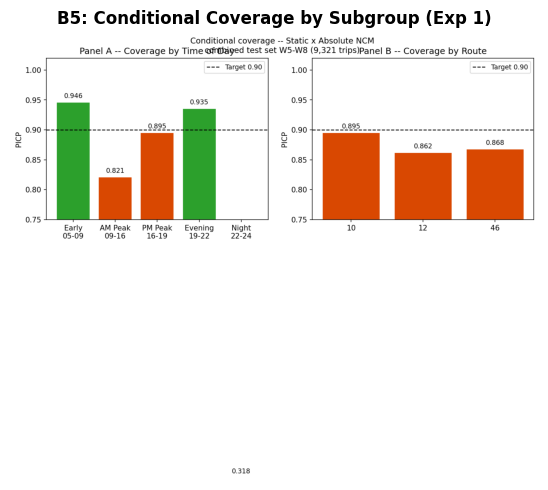

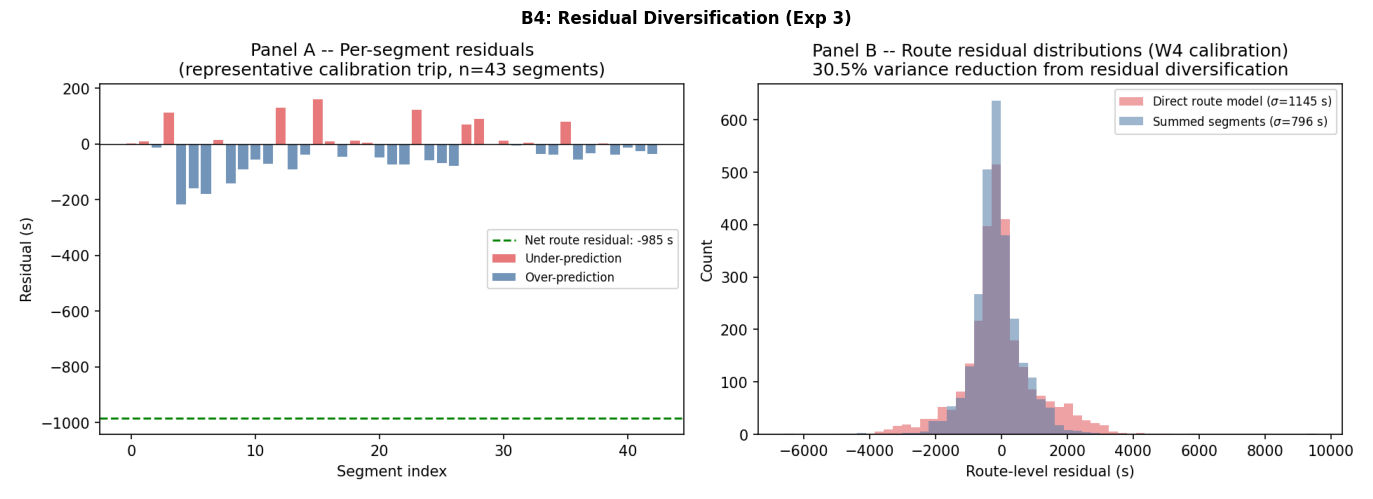

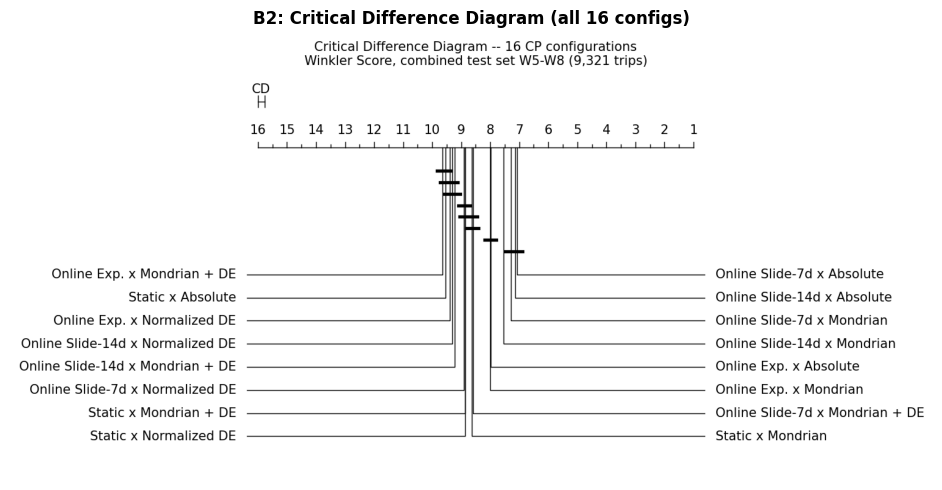

In [17]:
import matplotlib.image as mpimg

figs_to_show = [
    ('exp1_conditional_coverage', 'B5: Conditional Coverage by Subgroup (Exp 1)'),
    ('exp3_residual_diversification', 'B4: Residual Diversification (Exp 3)'),
    ('autorank_cd', 'B2: Critical Difference Diagram (all 16 configs)'),
]

for fname, title in figs_to_show:
    fpath = os.path.join(FIG_DIR, f'{fname}.png')
    if os.path.exists(fpath):
        fig, ax = plt.subplots(figsize=(14, 5))
        img = mpimg.imread(fpath)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Figure not yet generated: {fpath}')


---
*End of reproducibility notebook. All key thesis results reproduced.*  
For detailed per-segment uncertainty attribution and full Experiment 3 analysis, see `notebooks/Phase6_Exp3_Segment_Decomposition.ipynb`.

## Supplementary figures & tables (append-only -- do not re-run full loop)
These cells depend on `ALL_RESULTS`, `test_all`, `cal_seg_df`, and the
fitted models already in memory from the cells above. Run from here
after a full notebook execution.

In [18]:
# S1 -- Conditional coverage heatmap (Static x Absolute)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = Path('..') / 'figures'
FIG_DIR.mkdir(exist_ok=True)

key = 'Static x Absolute'
res = ALL_RESULTS[key]
lower, upper = np.array(res['lower']), np.array(res['upper'])
y_true = test_all['total_travel_time_seconds'].values

covered = (y_true >= lower) & (y_true <= upper)

# time-of-day bins
hour = test_all['hour_of_day']
bins   = [5, 9, 16, 19, 22, 24]
labels = ['Early\n05-09', 'AM Peak\n09-16', 'PM Peak\n16-19',
          'Evening\n19-22', 'Night\n22-24']
tod = pd.cut(hour, bins=bins, labels=labels, right=False)

routes = test_all['route_short_name'].values

df = pd.DataFrame({'covered': covered, 'tod': tod, 'route': routes})
df = df.dropna(subset=['tod'])

picp_tod   = df.groupby('tod',   observed=True)['covered'].mean()
picp_route = df.groupby('route', observed=True)['covered'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel A -- time of day
ax = axes[0]
colors_a = ['#d94801' if v < 0.9 else '#2ca02c' for v in picp_tod]
bars = ax.bar(picp_tod.index, picp_tod.values, color=colors_a, edgecolor='white')
ax.axhline(0.90, color='black', linestyle='--', linewidth=1.2, label='Target 0.90')
ax.set_ylim(0.75, 1.02)
ax.set_ylabel('PICP')
ax.set_title('Panel A -- Coverage by Time of Day')
ax.legend(fontsize=9)
for bar, v in zip(bars, picp_tod.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9)

# Panel B -- route
ax = axes[1]
colors_b = ['#d94801' if v < 0.9 else '#2ca02c' for v in picp_route]
bars = ax.bar(picp_route.index.astype(str), picp_route.values,
             color=colors_b, edgecolor='white')
ax.axhline(0.90, color='black', linestyle='--', linewidth=1.2, label='Target 0.90')
ax.set_ylim(0.75, 1.02)
ax.set_ylabel('PICP')
ax.set_title('Panel B -- Coverage by Route')
ax.legend(fontsize=9)
for bar, v in zip(bars, picp_route.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9)

fig.suptitle('Conditional coverage -- Static x Absolute NCM\n'
             'combined test set W5-W8 (9,321 trips)', fontsize=11)
fig.tight_layout()
out = FIG_DIR / 'exp1_conditional_coverage.pdf'
fig.savefig(out, bbox_inches='tight')
fig.savefig(FIG_DIR / 'exp1_conditional_coverage.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print('Saved:', out)
print('By time-of-day:', picp_tod.round(4).to_dict())
print('By route:',       picp_route.round(4).to_dict())


/var/folders/xz/4b0x_9ld4gx0p8z6mnzflfsr0000gn/T/ipykernel_48467/494146226.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


Saved: ../figures/exp1_conditional_coverage.pdf
By time-of-day: {'Early\n05-09': 0.9461, 'AM Peak\n09-16': 0.821, 'PM Peak\n16-19': 0.8951, 'Evening\n19-22': 0.9355, 'Night\n22-24': 0.3182}
By route: {10: 0.8951, 12: 0.8619, 46: 0.8677}


In [19]:
# S2 -- Autorank CD diagram across 16 configurations
# pip install autorank  (already in requirements.txt)
from pathlib import Path
import numpy as np
import pandas as pd
try:
    import autorank
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'autorank'])
    import autorank
import matplotlib.pyplot as plt

FIG_DIR = Path('..') / 'figures'
FIG_DIR.mkdir(exist_ok=True)

y_true = test_all['total_travel_time_seconds'].values
alpha_cp = 0.90

scores_dict = {}
for key, res in ALL_RESULTS.items():
    lo = np.array(res['lower'])
    hi = np.array(res['upper'])
    covered = (y_true >= lo) & (y_true <= hi)
    w = np.where(covered, hi - lo,
                 hi - lo + 2/alpha_cp * np.maximum(lo - y_true, y_true - hi))
    scores_dict[key] = w

df_scores = pd.DataFrame(scores_dict)

result = autorank.autorank(df_scores, alpha=0.05, verbose=False)
print(result)

fig, ax = plt.subplots(figsize=(10, 5))
autorank.plot_stats(result, ax=ax)
ax.set_title('Critical Difference Diagram -- 16 CP configurations\n'
             'Winkler Score, combined test set W5-W8 (9,321 trips)', fontsize=10)
fig.tight_layout()
out = FIG_DIR / 'autorank_cd.pdf'
fig.savefig(out, bbox_inches='tight')
fig.savefig(FIG_DIR / 'autorank_cd.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print('Saved:', out)


                                  meanrank       median          mad  \
Online Exp. x Mondrian + DE       9.643225  3169.471242  2033.838558   
Static x Absolute                 9.547527  3962.433594          0.0   
Online Exp. x Normalized DE       9.389282  3222.288012  2097.514705   
Online Slide-14d x Normalized DE  9.311179  3354.436576   2175.87702   
Online Slide-14d x Mondrian + DE  9.220845  3374.526928  2190.282076   
Online Slide-7d x Normalized DE   8.916747  3507.277469   2307.61441   
Static x Mondrian + DE            8.858223  3122.298331  2076.169247   
Static x Normalized DE            8.858062  3242.889091  2197.043212   
Static x Mondrian                 8.635393  4035.101562   772.222656   
Online Slide-7d x Mondrian + DE   8.592587  3467.449678  2277.507124   
Online Exp. x Mondrian            7.996352  4369.342285   659.792969   
Online Exp. x Absolute            7.977363  4269.848633    13.765625   
Online Slide-14d x Mondrian       7.551175  4559.480469    725.6

/Users/korayduzgun/Master/Courses/FinalProject/ImplementationV2/bus-eta-uncertainty/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9321.
  res = hypotest_fun_out(*samples, **kwds)
/Users/korayduzgun/Master/Courses/FinalProject/ImplementationV2/bus-eta-uncertainty/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9321.
  res = hypotest_fun_out(*samples, **kwds)
/Users/korayduzgun/Master/Courses/FinalProject/ImplementationV2/bus-eta-uncertainty/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9321.
  res = hypotest_fun_out(*samples, **kwds)
/Users/korayduzgun/Master/Courses/FinalProject/ImplementationV2/bus-eta-uncertainty/.ven

In [20]:
# S3 -- Residual diversification figure (Panel A: trip residuals, Panel B: distributions)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = Path('..') / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# --- Panel A: per-segment residuals for a representative calibration trip ---
cal_seg_df['seg_pred'] = seg_model.predict(cal_seg_df[SEG_FEATURES].values)

trip_sizes = cal_seg_df.groupby('trip_id').size()
rep_trip = trip_sizes[trip_sizes >= 20].index[0]
trip_df = cal_seg_df[cal_seg_df['trip_id'] == rep_trip].copy()
trip_df = trip_df.sort_values('segment_number_normalized')
seg_residuals = trip_df['run_time_in_seconds'].values - trip_df['seg_pred'].values
net = seg_residuals.sum()

# --- Panel B: direct vs summed-segment route residual distributions ---
direct_resid = y_cal - route_model.predict(X_cal)
seg_sum_resid = cal_agg['residual'].values

sigma_direct = direct_resid.std()
sigma_seg    = seg_sum_resid.std()
reduction_pct = (1 - sigma_seg / sigma_direct) * 100
print(f'sigma_direct   = {sigma_direct:.1f} s')
print(f'sigma_seg_sum  = {sigma_seg:.1f} s')
print(f'Reduction      = {reduction_pct:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel A
ax = axes[0]
x = np.arange(len(seg_residuals))
ax.bar(x[seg_residuals >= 0], seg_residuals[seg_residuals >= 0],
       color='#e15759', alpha=0.8, label='Under-prediction')
ax.bar(x[seg_residuals < 0], seg_residuals[seg_residuals < 0],
       color='#4e79a7', alpha=0.8, label='Over-prediction')
ax.axhline(net, color='green', linestyle='--', linewidth=1.4,
           label=f'Net route residual: {net:.0f} s')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xlabel('Segment index')
ax.set_ylabel('Residual (s)')
ax.set_title(f'Panel A -- Per-segment residuals\n(representative calibration trip, n={len(seg_residuals)} segments)')
ax.legend(fontsize=8)

# Panel B
ax = axes[1]
bins = np.linspace(
    min(direct_resid.min(), seg_sum_resid.min()),
    max(direct_resid.max(), seg_sum_resid.max()),
    60
)
ax.hist(direct_resid, bins=bins, alpha=0.55, color='#e15759',
        label=f'Direct route model ($\\sigma$={sigma_direct:.0f} s)')
ax.hist(seg_sum_resid, bins=bins, alpha=0.55, color='#4e79a7',
        label=f'Summed segments ($\\sigma$={sigma_seg:.0f} s)')
ax.set_xlabel('Route-level residual (s)')
ax.set_ylabel('Count')
ax.set_title(f'Panel B -- Route residual distributions (W4 calibration)\n'
             f'{reduction_pct:.1f}% variance reduction from residual diversification')
ax.legend(fontsize=8)

fig.tight_layout()
out = FIG_DIR / 'exp3_residual_diversification.pdf'
fig.savefig(out, bbox_inches='tight')
fig.savefig(FIG_DIR / 'exp3_residual_diversification.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print('Saved:', out)

sigma_direct   = 1145.2 s
sigma_seg_sum  = 795.7 s
Reduction      = 30.5%
Saved: ../figures/exp3_residual_diversification.pdf


In [23]:
# === Asymmetric (signed) variant of route-level re-calibration ===
# Goal: compare the symmetric (|R|, single quantile, +/- q) formulation
# currently used in Cell 21 against the asymmetric (signed R, two
# quantiles, low/high) formulation used by the library in Exp 1-2.
# Residuals here are signed: R_i = y_actual - y_pred (positive = late, negative = early).

ALPHA = 0.10  # 90% target coverage

def conformal_interval_signed_global(cal_residuals, test_preds, alpha=ALPHA):
    """Asymmetric split CP: low/high percentiles of signed residuals."""
    q_lo = np.percentile(cal_residuals, 100 * alpha / 2)        # typically negative
    q_hi = np.percentile(cal_residuals, 100 * (1 - alpha / 2))  # typically positive
    return test_preds + q_lo, test_preds + q_hi, q_lo, q_hi

def conformal_interval_per_group_signed(cal_agg, test_agg, group_cols,
                                         alpha=ALPHA, min_n=10):
    """Per-group asymmetric CP, with global fallback when group too small."""
    cal_res_global = cal_agg['residual'].values
    q_lo_global = np.percentile(cal_res_global, 100 * alpha / 2)
    q_hi_global = np.percentile(cal_res_global, 100 * (1 - alpha / 2))

    lo = np.zeros(len(test_agg))
    up = np.zeros(len(test_agg))
    for i, row in test_agg.iterrows():
        mask_cal = np.ones(len(cal_agg), dtype=bool)
        for col in group_cols:
            mask_cal &= (cal_agg[col] == row[col])
        sub_res = cal_agg.loc[mask_cal, 'residual'].values
        if len(sub_res) >= min_n:
            q_lo = np.percentile(sub_res, 100 * alpha / 2)
            q_hi = np.percentile(sub_res, 100 * (1 - alpha / 2))
        else:
            q_lo, q_hi = q_lo_global, q_hi_global
        lo[i] = row['y_pred'] + q_lo
        up[i] = row['y_pred'] + q_hi
    return lo, up

# --- 1. Global asymmetric ---
lo_g_a, up_g_a, ql_g, qh_g = conformal_interval_signed_global(
    cal_agg['residual'].values, test_agg['y_pred'].values)
picp_g_a = compute_picp(test_agg['y_actual'].values, lo_g_a, up_g_a)
mpiw_g_a = compute_mpiw(lo_g_a, up_g_a)
wink_g_a = compute_winkler_score(test_agg['y_actual'].values, lo_g_a, up_g_a, ALPHA)

# --- 2. Per-route signed ---
lo_r_a, up_r_a = conformal_interval_per_group_signed(
    cal_agg, test_agg, group_cols=['route', 'direction'])
picp_r_a = compute_picp(test_agg['y_actual'].values, lo_r_a, up_r_a)
mpiw_r_a = compute_mpiw(lo_r_a, up_r_a)
wink_r_a = compute_winkler_score(test_agg['y_actual'].values, lo_r_a, up_r_a, ALPHA)

# --- Symmetric reference (recompute for fairness) ---
q_sym_global = np.percentile(np.abs(cal_agg['residual'].values), (1 - ALPHA) * 100)

# Print comparison
print('=' * 75)
print(f"{'Method':<35} {'PICP':>8} {'MPIW (s)':>10} {'Winkler':>10}")
print('=' * 75)
print(f"{'Re-Cal Global    SYMMETRIC (|R|)':<35} "
      f"{0.8790:>8.4f} {2502:>10} {4287:>10}  (current)")
print(f"{'Re-Cal Global    ASYMMETRIC':<35} "
      f"{picp_g_a:>8.4f} {mpiw_g_a:>10.0f} {wink_g_a:>10.0f}")
print(f"{'Re-Cal Per-Route SYMMETRIC (|R|)':<35} "
      f"{0.8882:>8.4f} {2323:>10} {4035:>10}  (current)")
print(f"{'Re-Cal Per-Route ASYMMETRIC':<35} "
      f"{picp_r_a:>8.4f} {mpiw_r_a:>10.0f} {wink_r_a:>10.0f}")
print('=' * 75)
print(f'\nGlobal signed quantiles:  q_low = {ql_g:>+7.0f} s   q_high = {qh_g:>+7.0f} s')
print(f'Global |R|-based quantile (one-sided): q_sym = {q_sym_global:>+7.0f} s')
print(f'Asymmetry check: |q_low| = {abs(ql_g):.0f}  vs  q_high = {qh_g:.0f}')
if abs(ql_g) < qh_g:
    print('-> Right-skewed: bus tends to be later than predicted more than earlier.')
else:
    print('-> Left-skewed or symmetric residuals.')

Method                                  PICP   MPIW (s)    Winkler
Re-Cal Global    SYMMETRIC (|R|)      0.8790       2502       4287  (current)
Re-Cal Global    ASYMMETRIC           0.8790       2507       4284
Re-Cal Per-Route SYMMETRIC (|R|)      0.8882       2323       4035  (current)
Re-Cal Per-Route ASYMMETRIC           0.8663       2217       4097

Global signed quantiles:  q_low =   -1316 s   q_high =   +1192 s
Global |R|-based quantile (one-sided): q_sym =   +1251 s
Asymmetry check: |q_low| = 1316  vs  q_high = 1192
-> Left-skewed or symmetric residuals.
